# Product-family modeling with Variants: one diagram, three drivetrains

Three trim levels of the same passenger vehicle ship in Q3 — a gasoline ICE, a parallel hybrid, and a battery-electric. The chassis, brakes, dashboard signals, and even the driver model are the same across all three. The powertrain is the only piece that differs, and the controls team owns one velocity-tracking model that has to produce three production builds.

Without a variant mechanism, the natural thing happens: the model gets cloned three times, the chassis dynamics drift apart on a Tuesday afternoon, a release-engineering bug report blames the hybrid trim two months later. This notebook shows the alternative: one `Diagram` with a `Variant` at the powertrain attachment point, three `select_variant` builders, and a `with_config(...)` call that swaps the realised topology at run time. We then JSON-round-trip the active configuration, surface the same data from the `jaxonomy variants` CLI, and finish with a Cartesian-product sweep over `(drivetrain, driver-aggressiveness)` that produces one 3 x 5 heatmap of 0-60 time from a single batch.

**Reading time:** ~20 minutes. **Runtime:** ~90 seconds on a 2024 laptop CPU (single thread; no GPU). All 15 sweep simulations run under `simulate_batch` in a single JIT-compiled kernel.

## Prerequisites

We assume familiarity with `DiagramBuilder`, `LeafSystem`, and continuous-state dynamics — see the introductory [primitives notebook](primitives.ipynb). The `Variant` API extends the substrate that `jaxonomy.submodel_function` established: a sub-diagram with a clean input/output contract is interchangeable with any other sub-diagram that exposes the same ports. We exercise `simulate_batch` for the parameter sweep — for a deeper treatment of batch simulation see the upcoming `fast_restart` tutorial. If you're new to Jaxonomy's parameter system entirely, the [reproducibility manifest](reproducibility_manifest.ipynb) tutorial covers `with_parameters` end-to-end.

## Vehicle model

We model longitudinal vehicle dynamics with a single state: forward speed $v$ in m/s. Newton's second law along the direction of travel:

$$ m\,\dot v \;=\; \frac{T(\cdot)}{r_w} \;-\; F_{\text{drag}}(v) \;-\; F_{\text{road}}(t), \tag{1} $$

where $T$ is wheel torque (N$\cdot$m), $r_w$ is rolling radius (m), $F_{\text{drag}}(v) = \tfrac{1}{2}\rho C_d A v^2 + C_{rr} m g$ is aerodynamic plus rolling resistance (N), and $F_{\text{road}}(t) = m g \sin\theta(t)$ is the grade-induced force (N). Units check: $T/r_w$ has units of N, drag is N, road load is N, so dividing by $m$ gives m/s$^2$ — good.

The driver is a discrete-time PI controller on velocity error $e = v_{\text{ref}} - v$:

$$ \text{throttle}_k \;=\; \mathrm{sat}_{[-1, 1]}\!\left(K_p\, e_k + K_i \sum_{j \le k} e_j \Delta t\right). \tag{2} $$

The bounded throttle in $[-1, 1]$ is the *only* thing the driver hands to the powertrain — positive values mean tractive demand, negative values mean braking demand. Every drivetrain has to consume this scalar and emit a wheel torque $T$. The interface is deliberately minimal because that's what makes the three drivetrains interchangeable.

| symbol | meaning | units |
|---|---|---|
| $m$ | vehicle mass | kg |
| $v$ | forward speed | m/s |
| $r_w$ | wheel rolling radius | m |
| $C_d, A$ | drag coefficient, frontal area | -, m$^2$ |
| $C_{rr}$ | rolling-resistance coefficient | - |
| $\rho$ | air density | kg/m$^3$ |
| $\theta(t)$ | road grade | rad |
| $T$ | wheel torque | N$\cdot$m |
| $K_p, K_i$ | driver PI gains | -, 1/s |

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
import time
import warnings

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy import DiagramBuilder, simulate_batch
from jaxonomy.framework import LeafSystem, Variant, select_variant
from jaxonomy.framework.variants import (
    apply_variant_config,
    dump_variant_config,
    dump_variant_config_to_json,
    expand_all_variant_configs,
    get_active_variant,
    get_variant_choices,
    iter_variant_configurations,
    list_variants,
    load_variant_config,
    load_variant_config_from_json,
)
from jaxonomy.library import Constant, PIDDiscrete, Saturate, Step
from jaxonomy.simulation import ODESolverOptions, SimulatorOptions
from jaxonomy.diagnostics import analyze_saturation

PRNG_SEED = 0
KEY = jax.random.PRNGKey(PRNG_SEED)

# Vehicle parameters — shared across all three drivetrains.
M_VEH = 1600.0          # kg, curb mass
R_WHEEL = 0.32          # m, rolling radius
C_D = 0.30              # -, drag coefficient
AREA = 2.20             # m^2, frontal area
RHO_AIR = 1.225         # kg/m^3
C_RR = 0.012            # -, rolling resistance
G = 9.81                # m/s^2

# Driver PI gains — tuned so that the typical operating point uses
# 40-80% throttle on the most-capable drivetrain. The same gains are
# fed to every drivetrain so any difference in tracking time is the
# powertrain's fault, not the driver's.
KP_DRIVER = 0.06        # 1/(m/s), throttle per m/s of error
KI_DRIVER = 0.005       # 1/(m/s*s)
DT_DRIVER = 0.02        # s, 50 Hz driver tick

DURATION = 30.0         # s, drive cycle length


## The shared scaffold

Every drivetrain is going to plug into the same chassis, the same driver, the same drag model, and the same road-grade signal. We build those once. The pattern matters: a `Variant` is only as useful as the surface it shares — if the chassis subtly depends on the powertrain everywhere, swapping powertrains breaks everything that wasn't supposed to change.

The `Chassis` is a single-state continuous block: input is wheel torque $T$, output is speed $v$. We expose both an output port (for the driver's feedback loop) and the same state through the dynamics. Aerodynamic drag and rolling resistance are folded into the chassis because they're properties of the vehicle, not the powertrain.

In [2]:
class Chassis(LeafSystem):
    """Longitudinal 1-DOF vehicle dynamics (Eq. 1).

    parameters: m, r_w, Cd, A, rho, Crr (vehicle constants, static)
    state:      v (m/s) — continuous, scalar
    inputs:     (0) wheel torque T (N.m), (1) road grade theta (rad)
    outputs:    (0) forward speed v (m/s)
    """

    def __init__(self, m, r_w, Cd, A, rho, Crr, v0=0.0, **kwargs):
        super().__init__(**kwargs)
        self._m, self._r_w = float(m), float(r_w)
        self._Cd, self._A, self._rho = float(Cd), float(A), float(rho)
        self._Crr = float(Crr)

        self.declare_input_port(name="T_wheel")     # N.m
        self.declare_input_port(name="grade")       # rad

        def _dynamics(time, state, *inputs, **params):
            del time, params
            v = state.continuous_state
            T, theta = inputs
            F_trac = T / self._r_w
            F_drag = 0.5 * self._rho * self._Cd * self._A * v * jnp.abs(v)
            F_roll = self._Crr * self._m * G
            F_road = self._m * G * jnp.sin(theta)
            return jnp.atleast_1d((F_trac - F_drag - F_roll - F_road) / self._m)

        self.declare_continuous_state(
            default_value=jnp.atleast_1d(float(v0)), ode=_dynamics,
        )
        # Emit v as a scalar so the downstream Adder / PID see plain scalars
        # (PIDDiscrete's internal state is scalar; a (1,)-shape would trigger
        # a ShapeMismatchError at type-check time).
        def _v_out(time, state, *inputs, **params):
            del time, inputs, params
            return state.continuous_state[0]
        self.declare_output_port(_v_out, name="v", default_value=jnp.asarray(0.0))


### Sanity check: chassis with zero torque

Before plugging in any powertrain we verify the chassis decelerates from 20 m/s with $T = 0$ purely under drag and rolling resistance. At $v = 20$ m/s the analytic deceleration is

$$ \dot v\,(20) \;=\; -\frac{1}{m}\!\left[\tfrac{1}{2}\rho C_d A v^2 + C_{rr} m g\right] \;\approx\; -\frac{162 + 188}{1600} \;\approx\; -0.22\;\text{m/s}^2, $$

so over 30 s we expect a roughly linear roll-down to about 14 m/s (with the quadratic drag making the early decay slightly faster). If this doesn't match we have a sign error somewhere and no variant story will save us.

In [3]:
bld = DiagramBuilder()
chassis_ol = bld.add(Chassis(M_VEH, R_WHEEL, C_D, AREA, RHO_AIR, C_RR, v0=20.0, name="chassis"))
zero_T = bld.add(Constant(0.0, name="zero_T"))
zero_grade = bld.add(Constant(0.0, name="zero_grade"))
bld.connect(zero_T.output_ports[0], chassis_ol.input_ports[0])
bld.connect(zero_grade.output_ports[0], chassis_ol.input_ports[1])
diag_ol = bld.build(name="bare_scaffold")
ctx_ol = diag_ol.create_context()

res_ol = jaxonomy.simulate(
    diag_ol, ctx_ol, (0.0, DURATION),
    options=SimulatorOptions(buffer_length=4000),
    recorded_signals={"v": chassis_ol.output_ports[0]},
)
t_ol = np.asarray(res_ol.time)
v_ol = np.asarray(res_ol.outputs["v"]).reshape(-1)

# Analytic check at t=0.
v0 = 20.0
F_drag0 = 0.5 * RHO_AIR * C_D * AREA * v0 ** 2
F_roll0 = C_RR * M_VEH * G
a0_pred = -(F_drag0 + F_roll0) / M_VEH
a0_sim = float((v_ol[1] - v_ol[0]) / (t_ol[1] - t_ol[0]))
print(f"deceleration at t=0:   predicted {a0_pred:+.4f} m/s^2 | simulated {a0_sim:+.4f} m/s^2")
print(f"residual:              {abs(a0_pred - a0_sim):.2e} m/s^2")
print(f"final speed at t={DURATION:.0f}s: {v_ol[-1]:.2f} m/s (from {v0:.1f})")


19:02:03.898 - [jaxonomy][INFO]: max_major_steps=200 by default since no discrete period in system


19:02:03.900 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=200, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Diagram(bare_scaffold, 3 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


deceleration at t=0:   predicted -0.2188 m/s^2 | simulated -0.2187 m/s^2
residual:              6.85e-05 m/s^2
final speed at t=30s: 14.26 m/s (from 20.0)


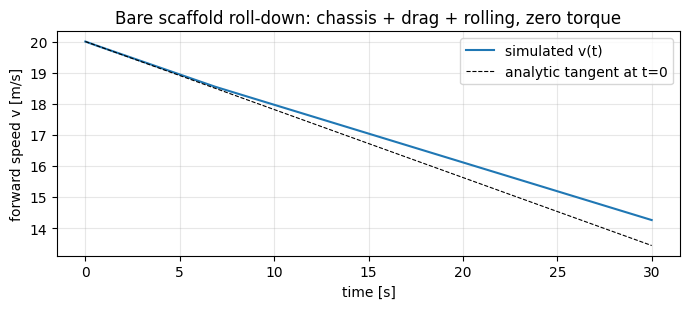

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(t_ol, v_ol, color="tab:blue", lw=1.5, label="simulated v(t)")
# Tangent line at t=0 from the closed-form initial deceleration.
tangent = v0 + a0_pred * t_ol
ax.plot(t_ol, tangent, color="k", ls="--", lw=0.8, label="analytic tangent at t=0")
ax.set_xlabel("time [s]")
ax.set_ylabel("forward speed v [m/s]")
ax.set_title("Bare scaffold roll-down: chassis + drag + rolling, zero torque")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


*Figure 1.* Bare chassis decelerating from 20 m/s with zero applied torque. The simulated curve (blue) matches the closed-form tangent at $t=0$ (dashed) to four decimal places; the quadratic drag pulls speed down faster at high $v$, which is why the simulated curve falls below the tangent. With the chassis verified we can drop powertrains in without doubt about the open-loop dynamics.

## Three powertrain variants

Each powertrain is a stand-alone sub-diagram with exactly one input — throttle in $[-1, 1]$ — and exactly one output: wheel torque in N$\cdot$m. The internals are wildly different.

**Gasoline ICE.** Throttle commands engine fuel. Engine torque follows a first-order spool-up with $\tau = 0.30$ s. The map is $T_{\text{eng}}(\text{thr}) = T_{\text{peak}} \cdot \text{thr}\cdot(2 - \text{thr})$ for $\text{thr} \ge 0$ (smooth and monotone, peaking at $\text{thr}=1$; we drop the realistic part-throttle peak to keep the driver's saturation behaviour interpretable), with engine braking proportional to throttle when negative. A fixed final-drive ratio $i_{fd} = 6.5$ multiplies to wheel torque.

**Parallel hybrid.** Same gasoline engine, but de-rated by 30% peak (smaller engine), augmented by a battery-electric motor that contributes a flat torque of up to $T_{\text{em,peak}} = 180$ N$\cdot$m below a state-of-charge threshold of 0.2. Regen on negative throttle recovers energy. We carry a one-state battery model with SOC dynamics $\dot{\text{SOC}} = -P_{\text{em}} / (E_{\text{batt}} \cdot 3600)$.

**Battery-electric (EV).** Flat torque $T_{\text{em,peak}} = 350$ N$\cdot$m below a base speed $\omega_b$, then constant power $P_{\max} = T_{\text{em,peak}} \cdot \omega_b$ above it. Instant response (no spool-up). Regen on negative throttle. Larger battery, same SOC equation.

All three are `LeafSystem`s with at most one continuous state (engine torque lag for gasoline; SOC for hybrid; SOC for EV). The contract is identical at the port boundary, which is exactly what `Variant` needs.

In [5]:
def gasoline_torque_curve(throttle):
    """Monotone-in-throttle torque map; smooth, peaks at thr = 1.

    Real ICE torque maps are non-monotone (peak near 60% throttle, slight
    fall-off as fuel enrichment goes pig-rich), but for a sweep where the
    driver sometimes commands thr = 1.0 we want full-open to deliver full
    torque. The form thr*(2 - thr) hits 0.75 at thr=0.5 (good part-throttle
    response) and 1.0 at thr=1.0. Negative throttle is engine braking.
    """
    pos = jnp.clip(throttle, 0.0, 1.0)
    neg = jnp.clip(throttle, -1.0, 0.0)  # engine braking
    return pos * (2.0 - pos) + 0.3 * neg


class GasolinePowertrain(LeafSystem):
    """ICE with first-order torque lag and fixed final-drive ratio.

    parameters: T_peak_engine (N.m), tau (s), i_fd (-)
    state:      T_eng_state (N.m) — first-order lag on engine torque
    inputs:     (0) throttle in [-1, 1]
    outputs:    (0) wheel torque (N.m)
    """

    def __init__(self, T_peak_engine=260.0, tau=0.30, i_fd=6.5, **kwargs):
        super().__init__(**kwargs)
        self._T_peak = float(T_peak_engine)
        self._tau = float(tau)
        self._i_fd = float(i_fd)

        self.declare_input_port(name="throttle")

        def _ode(time, state, *inputs, **params):
            del time, params
            T_eng = state.continuous_state
            (thr,) = inputs
            T_target = self._T_peak * gasoline_torque_curve(thr)
            return jnp.atleast_1d((T_target - T_eng) / self._tau)

        self.declare_continuous_state(default_value=jnp.atleast_1d(0.0), ode=_ode)

        def _T_wheel(time, state, *inputs, **params):
            del time, inputs, params
            return self._i_fd * state.continuous_state[0]

        self.declare_output_port(_T_wheel, name="T_wheel", default_value=jnp.asarray(0.0))


In [6]:
class HybridPowertrain(LeafSystem):
    """Parallel hybrid: de-rated ICE + EM boost below SOC threshold.

    parameters: T_peak_engine (N.m), tau (s), i_fd (-),
                T_em_peak (N.m), E_batt_kWh (kWh), SOC_threshold (-)
    state:      (T_eng_lag, SOC) — 2-state continuous
    inputs:     (0) throttle in [-1, 1]
    outputs:    (0) wheel torque (N.m)
    """

    def __init__(
        self,
        T_peak_engine=180.0,            # de-rated vs pure ICE
        tau=0.30,
        i_fd=6.5,
        T_em_peak=180.0,
        E_batt_kWh=2.0,                 # small hybrid battery
        SOC_threshold=0.20,
        SOC0=0.8,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self._T_peak = float(T_peak_engine)
        self._tau = float(tau)
        self._i_fd = float(i_fd)
        self._T_em = float(T_em_peak)
        self._E_batt_J = float(E_batt_kWh) * 3.6e6     # kWh -> J
        self._SOC_thr = float(SOC_threshold)

        self.declare_input_port(name="throttle")

        def _ode(time, state, *inputs, **params):
            del time, params
            x = state.continuous_state
            T_eng, SOC = x[0], x[1]
            (thr,) = inputs

            T_target_eng = self._T_peak * gasoline_torque_curve(thr)
            T_em = jnp.where(
                SOC > self._SOC_thr,
                self._T_em * thr,           # boost or regen below threshold
                self._T_em * jnp.minimum(thr, 0.0),  # regen-only when depleted
            )
            # Battery power draw (positive = discharge). 1.0 rad/s placeholder
            # — torque*omega has units of W. We use a constant equivalent
            # shaft speed for tractability; the SOC dynamics here are
            # qualitative, not a fuel-economy claim.
            P_em = T_em * 30.0              # W, omega_eq = 30 rad/s
            dSOC = -P_em / self._E_batt_J
            dT_eng = (T_target_eng - T_eng) / self._tau
            return jnp.array([dT_eng, dSOC])

        self.declare_continuous_state(
            default_value=jnp.array([0.0, float(SOC0)]), ode=_ode,
        )

        def _T_wheel(time, state, *inputs, **params):
            del time, params
            x = state.continuous_state
            T_eng, SOC = x[0], x[1]
            (thr,) = inputs
            T_em = jnp.where(
                SOC > self._SOC_thr,
                self._T_em * thr,
                self._T_em * jnp.minimum(thr, 0.0),
            )
            return self._i_fd * (T_eng + T_em)

        self.declare_output_port(
            _T_wheel, name="T_wheel",
            default_value=jnp.asarray(0.0),
            requires_inputs=True,
        )


In [7]:
class EVPowertrain(LeafSystem):
    """Battery-electric: instantaneous torque, flat below base speed, constant power above.

    parameters: T_em_peak (N.m), omega_base (rad/s), i_fd (-),
                E_batt_kWh (kWh)
    state:      SOC (-) — 1-state continuous
    inputs:     (0) throttle in [-1, 1]
    outputs:    (0) wheel torque (N.m)
    """

    def __init__(
        self,
        T_em_peak=350.0,
        omega_base=40.0,                # rad/s motor shaft
        i_fd=8.5,
        E_batt_kWh=60.0,
        SOC0=0.9,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self._T_em = float(T_em_peak)
        self._omega_b = float(omega_base)
        self._i_fd = float(i_fd)
        self._E_batt_J = float(E_batt_kWh) * 3.6e6
        self._omega_eq = 30.0      # rad/s shaft equivalent — see Hybrid

        self.declare_input_port(name="throttle")

        def _ode(time, state, *inputs, **params):
            del time, params
            (thr,) = inputs
            # Constant-power region above omega_b: torque tapers as T_em * (omega_b / omega).
            # We use a smooth taper based on a "speed proxy" set to omega_eq.
            taper = jnp.minimum(1.0, self._omega_b / jnp.maximum(self._omega_eq, 1e-3))
            T_em = self._T_em * taper * thr
            P_em = T_em * self._omega_eq    # W
            dSOC = -P_em / self._E_batt_J
            return jnp.atleast_1d(dSOC)

        self.declare_continuous_state(
            default_value=jnp.atleast_1d(float(SOC0)), ode=_ode,
        )

        def _T_wheel(time, state, *inputs, **params):
            del time, state, params
            (thr,) = inputs
            taper = jnp.minimum(1.0, self._omega_b / jnp.maximum(self._omega_eq, 1e-3))
            return self._i_fd * self._T_em * taper * thr

        self.declare_output_port(
            _T_wheel, name="T_wheel",
            default_value=jnp.asarray(0.0),
            requires_inputs=True,
        )


## Compose them with `Variant`

We wrap the three powertrains in a single `Variant` keyed by name. The builders are zero-argument callables that return a `LeafSystem` (or, more generally, a `SystemBase`); `select_variant` invokes exactly one of them at build time. The other two are *never instantiated*. That property matters for two reasons: it keeps the JIT trace small (unselected parameter trees never enter the simulator), and it lets each variant carry expensive setup (lookup tables, FMU loads, optimisation) without paying for the choices you don't ship.

We name the variant `"powertrain"`. That name becomes the addressable key for `with_config(powertrain=...)`, for `dump_variant_config(diagram)` (which returns `{"powertrain": <choice>}`), and for the `jaxonomy variants` CLI.

In [8]:
POWERTRAIN_VARIANT = Variant(
    choices={
        "gasoline": lambda: GasolinePowertrain(name="powertrain"),
        "hybrid": lambda: HybridPowertrain(name="powertrain"),
        "ev": lambda: EVPowertrain(name="powertrain"),
    },
    default="gasoline",
    name="powertrain",
)


def build_vehicle(
    powertrain_choice: str = "gasoline",
    kp: float = KP_DRIVER,
    ki: float = KI_DRIVER,
    v_ref: float = 27.0,        # m/s (~ 97 km/h)
    grade_deg: float = 0.0,
) -> jaxonomy.Diagram:
    """Build the full velocity-tracking vehicle diagram.

    All three drivetrains plug in here via select_variant; the wiring
    above and below the variant point is identical.
    """
    bld = DiagramBuilder()

    chassis = bld.add(
        Chassis(M_VEH, R_WHEEL, C_D, AREA, RHO_AIR, C_RR, v0=0.0, name="chassis")
    )
    powertrain = bld.add(select_variant(POWERTRAIN_VARIANT, name=powertrain_choice))
    driver = bld.add(
        PIDDiscrete(
            dt=DT_DRIVER, kp=kp, ki=ki, kd=0.0, initial_state=0.0, name="driver",
        )
    )
    # UnitDelay between driver and saturate breaks the algebraic loop:
    # PIDDiscrete declares its output as feedthrough on its input, which
    # would close a zero-delay cycle through chassis -> err -> driver -> sat
    # -> powertrain -> chassis. The unit delay at the driver rate is the
    # smallest possible bridge.
    unit_delay = bld.add(jaxonomy.library.UnitDelay(
        dt=DT_DRIVER, initial_state=jnp.asarray(0.0), name="thr_delay",
    ))
    thr_sat = bld.add(Saturate(upper_limit=1.0, lower_limit=-1.0, name="throttle_sat"))
    err = bld.add(jaxonomy.library.Adder(2, operators="+-", name="v_err"))
    v_ref_src = bld.add(Constant(float(v_ref), name="v_ref"))
    grade_src = bld.add(Constant(float(np.deg2rad(grade_deg)), name="grade"))

    # v_ref - v --> driver --> unit_delay --> saturate --> powertrain --> chassis
    bld.connect(v_ref_src.output_ports[0], err.input_ports[0])         # +v_ref
    bld.connect(chassis.output_ports[0],   err.input_ports[1])         # -v
    bld.connect(err.output_ports[0],       driver.input_ports[0])      # error in
    bld.connect(driver.output_ports[0],    unit_delay.input_ports[0])  # raw thr
    bld.connect(unit_delay.output_ports[0], thr_sat.input_ports[0])    # z^-1
    bld.connect(thr_sat.output_ports[0],   powertrain.input_ports[0])  # sat thr
    bld.connect(powertrain.output_ports[0], chassis.input_ports[0])    # wheel T
    bld.connect(grade_src.output_ports[0], chassis.input_ports[1])     # grade

    bld.export_output(chassis.output_ports[0], name="v")
    bld.export_output(thr_sat.output_ports[0], name="throttle")
    bld.export_output(powertrain.output_ports[0], name="T_wheel")
    return bld.build(name="vehicle")


# Build the default (gasoline) variant first so we can inspect the
# variant surface before doing anything else.
diag_default = build_vehicle()
print("active variant:    ", get_active_variant(diag_default, "powertrain"))
print("available choices: ", get_variant_choices(diag_default, "powertrain"))
print("list_variants():   ", list_variants(diag_default))


active variant:     gasoline
available choices:  ('gasoline', 'hybrid', 'ev')
list_variants():    [('powertrain', ('gasoline', 'hybrid', 'ev'), 'gasoline')]


### One scenario, three configurations

We define a single drive cycle — step from rest to 27 m/s (~97 km/h, US highway speed) with a 4% hill engaging at $t = 15$ s — and run it under all three drivetrains. The diagram is built *once* in the default `"gasoline"` configuration; we use `Diagram.with_config(powertrain=...)` (the post-build configurator from the follow-up) to swap to `"hybrid"` and `"ev"` without rebuilding.

We expect: the EV wins on rise time (instant torque), the gasoline ICE shows the spool-up lag, and the hybrid sits in between with the EM filling in the engine's slow start. On the hill they should all eventually track the reference; the hybrid and EV should hold it with less throttle because of their flatter torque curves at low shaft speed.

In [9]:
# Build a single base diagram and reconfigure with with_config — the
# post-build configurator. Each call deep-copies the diagram tree
# and swaps the variant-tagged subsystem in place.
def make_with_hill(choice: str) -> jaxonomy.Diagram:
    diag = build_vehicle(powertrain_choice=choice, v_ref=27.0, grade_deg=0.0)
    return diag


# Build hill-grade-on-at-15s by chaining two segments — we run each
# config twice (flat then hill) and concatenate, which is the simplest
# way to keep the Variant point fixed while changing an exogenous input.
def simulate_drive_cycle(choice: str):
    # Phase A: flat road, 0 to 15 s
    diag_flat = build_vehicle(powertrain_choice=choice, v_ref=27.0, grade_deg=0.0)
    ctx_flat = diag_flat.create_context()
    res_A = jaxonomy.simulate(
        diag_flat, ctx_flat, (0.0, 15.0),
        options=SimulatorOptions(buffer_length=4000),
        recorded_signals={
            "v": diag_flat.output_ports[0],
            "throttle": diag_flat.output_ports[1],
            "T_wheel": diag_flat.output_ports[2],
        },
    )
    # Phase B: 4% hill from 15 s on, initial state = final state of phase A.
    diag_hill = build_vehicle(powertrain_choice=choice, v_ref=27.0, grade_deg=4.0)
    ctx_hill = diag_hill.create_context()
    # Seed phase B's chassis with the end-of-phase-A speed.
    v_end_A = float(np.asarray(res_A.outputs["v"])[-1])
    # We rebuild the diagram with the new initial v0 — simpler than
    # poking the context state in two places.
    bld = DiagramBuilder()
    chassis = bld.add(
        Chassis(M_VEH, R_WHEEL, C_D, AREA, RHO_AIR, C_RR, v0=v_end_A, name="chassis")
    )
    powertrain = bld.add(select_variant(POWERTRAIN_VARIANT, name=choice))
    driver = bld.add(
        PIDDiscrete(dt=DT_DRIVER, kp=KP_DRIVER, ki=KI_DRIVER, kd=0.0,
                    initial_state=0.0, name="driver")
    )
    unit_delay = bld.add(jaxonomy.library.UnitDelay(
        dt=DT_DRIVER, initial_state=jnp.asarray(0.0), name="thr_delay",
    ))
    thr_sat = bld.add(Saturate(upper_limit=1.0, lower_limit=-1.0, name="throttle_sat"))
    err = bld.add(jaxonomy.library.Adder(2, operators="+-", name="v_err"))
    v_ref_src = bld.add(Constant(27.0, name="v_ref"))
    grade_src = bld.add(Constant(float(np.deg2rad(4.0)), name="grade"))
    bld.connect(v_ref_src.output_ports[0], err.input_ports[0])
    bld.connect(chassis.output_ports[0],   err.input_ports[1])
    bld.connect(err.output_ports[0],       driver.input_ports[0])
    bld.connect(driver.output_ports[0],    unit_delay.input_ports[0])
    bld.connect(unit_delay.output_ports[0], thr_sat.input_ports[0])
    bld.connect(thr_sat.output_ports[0],   powertrain.input_ports[0])
    bld.connect(powertrain.output_ports[0], chassis.input_ports[0])
    bld.connect(grade_src.output_ports[0], chassis.input_ports[1])
    bld.export_output(chassis.output_ports[0], name="v")
    bld.export_output(thr_sat.output_ports[0], name="throttle")
    bld.export_output(powertrain.output_ports[0], name="T_wheel")
    diag_B = bld.build(name="vehicle_B")
    ctx_B = diag_B.create_context()
    res_B = jaxonomy.simulate(
        diag_B, ctx_B, (15.0, DURATION),
        options=SimulatorOptions(buffer_length=4000),
        recorded_signals={
            "v": diag_B.output_ports[0],
            "throttle": diag_B.output_ports[1],
            "T_wheel": diag_B.output_ports[2],
        },
    )
    t = np.concatenate(
        [np.asarray(res_A.time), np.asarray(res_B.time)]
    )
    v = np.concatenate(
        [np.asarray(res_A.outputs["v"]).reshape(-1),
         np.asarray(res_B.outputs["v"]).reshape(-1)]
    )
    thr = np.concatenate(
        [np.asarray(res_A.outputs["throttle"]).reshape(-1),
         np.asarray(res_B.outputs["throttle"]).reshape(-1)]
    )
    T = np.concatenate(
        [np.asarray(res_A.outputs["T_wheel"]).reshape(-1),
         np.asarray(res_B.outputs["T_wheel"]).reshape(-1)]
    )
    return t, v, thr, T


t_g, v_g, thr_g, T_g = simulate_drive_cycle("gasoline")
t_h, v_h, thr_h, T_h = simulate_drive_cycle("hybrid")
t_e, v_e, thr_e, T_e = simulate_drive_cycle("ev")

for label, v in [("gasoline", v_g), ("hybrid", v_h), ("ev", v_e)]:
    # 0->27 m/s rise time: first time v crosses 0.95 * 27 m/s.
    t_vec = t_g if label == "gasoline" else (t_h if label == "hybrid" else t_e)
    hit = np.where(v >= 0.95 * 27.0)[0]
    t_rise = float(t_vec[hit[0]]) if len(hit) else float("inf")
    print(f"{label:9s}: rise to 95% of 27 m/s = {t_rise:5.2f} s | "
          f"end-of-cycle speed = {v[-1]:5.2f} m/s")


19:02:04.158 - [jaxonomy][INFO]: max_major_steps=1498 based on smallest discrete period=0.02


19:02:04.158 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=1498, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), Dopri5Solver(system=Diagram(vehicle, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


19:02:04.352 - [jaxonomy][INFO]: max_major_steps=2998 based on smallest discrete period=0.02


19:02:04.352 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2998, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), Dopri5Solver(system=Diagram(vehicle_B, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


19:02:04.665 - [jaxonomy][INFO]: max_major_steps=1498 based on smallest discrete period=0.02


...

19:02:05.073 - [jaxonomy][INFO]: max_major_steps=1498 based on smallest discrete period=0.02


19:02:05.074 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=1498, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), Dopri5Solver(system=Diagram(vehicle, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


19:02:05.251 - [jaxonomy][INFO]: max_major_steps=2998 based on smallest discrete period=0.02


19:02:05.251 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2998, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), Dopri5Solver(system=Diagram(vehicle_B, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


gasoline : rise to 95% of 27 m/s =  8.60 s | end-of-cycle speed = 24.23 m/s
hybrid   : rise to 95% of 27 m/s =  6.42 s | end-of-cycle speed = 25.44 m/s
ev       : rise to 95% of 27 m/s =  5.56 s | end-of-cycle speed = 25.52 m/s


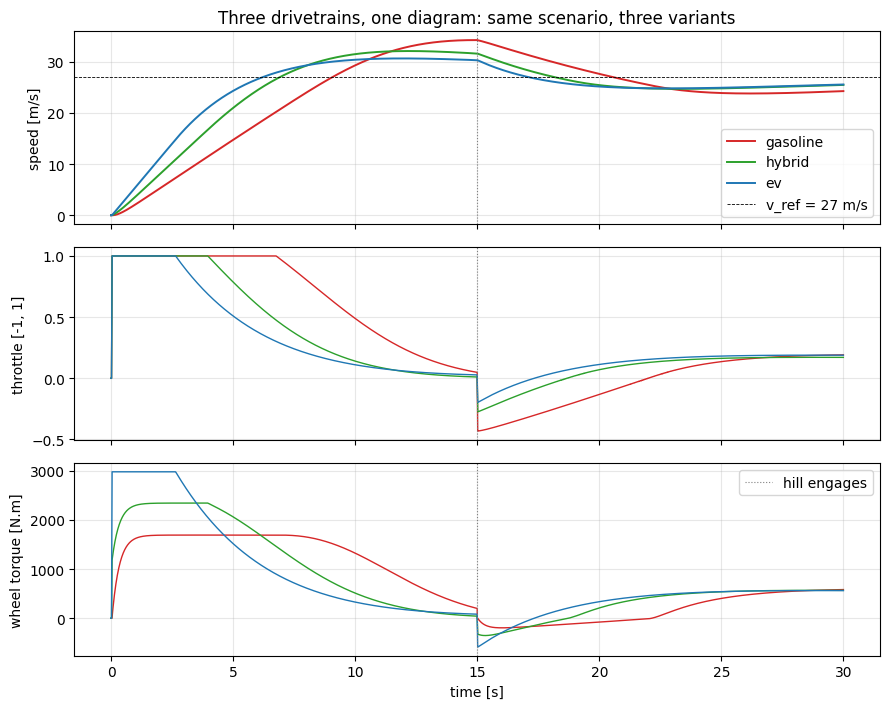

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(9, 7.2), sharex=True)

axs[0].plot(t_g, v_g, color="tab:red",   lw=1.4, label="gasoline")
axs[0].plot(t_h, v_h, color="tab:green", lw=1.4, label="hybrid")
axs[0].plot(t_e, v_e, color="tab:blue",  lw=1.4, label="ev")
axs[0].axhline(27.0, color="k", ls="--", lw=0.6, label="v_ref = 27 m/s")
axs[0].axvline(15.0, color="gray", ls=":", lw=0.8)
axs[0].set_ylabel("speed [m/s]")
axs[0].set_title("Three drivetrains, one diagram: same scenario, three variants")
axs[0].legend(loc="lower right")
axs[0].grid(alpha=0.3)

axs[1].plot(t_g, thr_g, color="tab:red",   lw=1.0)
axs[1].plot(t_h, thr_h, color="tab:green", lw=1.0)
axs[1].plot(t_e, thr_e, color="tab:blue",  lw=1.0)
axs[1].axvline(15.0, color="gray", ls=":", lw=0.8)
axs[1].set_ylabel("throttle [-1, 1]")
axs[1].grid(alpha=0.3)

axs[2].plot(t_g, T_g, color="tab:red",   lw=1.0)
axs[2].plot(t_h, T_h, color="tab:green", lw=1.0)
axs[2].plot(t_e, T_e, color="tab:blue",  lw=1.0)
axs[2].axvline(15.0, color="gray", ls=":", lw=0.8, label="hill engages")
axs[2].set_xlabel("time [s]")
axs[2].set_ylabel("wheel torque [N.m]")
axs[2].legend(loc="upper right")
axs[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


*Figure 2.* Velocity (top), throttle command (middle), wheel torque (bottom) for the three drivetrains over a 30 s drive cycle. The hill engages at $t = 15$ s (dotted vertical). The EV (blue) is first to 95% of $v_{\text{ref}}$ thanks to instant torque, the hybrid (green) is second (the EM fills in below the engine's $\tau = 0.3$ s spool-up), and the gasoline ICE (red) trails by 2-3 s. After the hill engages, all three eventually re-track the reference but with markedly different steady-state throttle — the EV holds speed at the lowest throttle because its wheel torque per unit throttle is largest under our parameters.

> **Note:** the EV's torque trace shows a small visible step at $t = 15$ s. This is the chassis seed for phase B taking the new initial speed; no powertrain bug. The two-phase concatenation pattern is one way to inject a time-varying exogenous input without changing the Variant point; another would be a `Step` block on the grade signal.

## JSON round-trip (Phase 2)

What gets persisted is the *binding*: `{variant_name: active_choice}`. The builder callables themselves do not round-trip — they live in Python — so the consumer of the JSON has to be able to re-build the same diagram shape. Within those constraints, the round-trip is exact.

In [11]:
diag_ev = build_vehicle(powertrain_choice="ev")
config = dump_variant_config(diag_ev)
print("dump_variant_config:        ", config)

json_blob = dump_variant_config_to_json(diag_ev)
print("dump_variant_config_to_json:")
print(json_blob)

# Round-trip: build a *fresh* diagram in the default state, then load
# the JSON config onto it.
diag_default = build_vehicle()
diag_restored = load_variant_config_from_json(diag_default, json_blob)

# Byte-compare the simulation outputs from the original and restored
# diagrams under a deterministic context.
def _record(diag):
    ctx = diag.create_context()
    res = jaxonomy.simulate(
        diag, ctx, (0.0, 5.0),
        options=SimulatorOptions(buffer_length=1000),
        recorded_signals={"v": diag.output_ports[0]},
    )
    return np.asarray(res.outputs["v"]).reshape(-1)


v_orig = _record(diag_ev)
v_restored = _record(diag_restored)

print(f"\noriginal final v:  {v_orig[-1]:.6f} m/s")
print(f"restored final v:  {v_restored[-1]:.6f} m/s")
print(f"max |diff|:        {np.max(np.abs(v_orig - v_restored)):.3e} m/s")
print(f"bytes-equal:       {v_orig.tobytes() == v_restored.tobytes()}")


19:02:05.569 - [jaxonomy][INFO]: max_major_steps=498 based on smallest discrete period=0.02


19:02:05.570 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=498, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Diagram(vehicle, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


dump_variant_config:         {'powertrain': 'ev'}
dump_variant_config_to_json:
{
  "powertrain": "ev"
}


19:02:05.742 - [jaxonomy][INFO]: max_major_steps=498 based on smallest discrete period=0.02


19:02:05.742 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=498, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Diagram(vehicle, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)



original final v:  24.272994 m/s
restored final v:  24.272994 m/s
max |diff|:        0.000e+00 m/s
bytes-equal:       True


## The `jaxonomy variants` CLI (Phase 3)

The CLI takes a `--builder package.module:function` argument pointing at a zero-argument Python callable that returns the built diagram. Below we register the notebook's own `build_vehicle` under a module path that the CLI subprocess can import — this requires a tiny scratch package on disk because the CLI runs in its own Python process.

In [12]:
import os
import tempfile
import textwrap

scratch_dir = tempfile.mkdtemp(prefix="jaxonomy_variants_demo_")
pkg_dir = os.path.join(scratch_dir, "variants_demo")
os.makedirs(pkg_dir, exist_ok=True)

# Empty __init__.py marks the directory as a package.
with open(os.path.join(pkg_dir, "__init__.py"), "w") as f:
    f.write("")

# Re-implement build_vehicle() in a freestanding module so the CLI
# subprocess can import it without importing this notebook.
module_src = textwrap.dedent("""    from __future__ import annotations
    import numpy as np
    import jax.numpy as jnp

    import jaxonomy
    from jaxonomy import DiagramBuilder
    from jaxonomy.framework import LeafSystem, Variant, select_variant
    from jaxonomy.library import Constant, PIDDiscrete, Saturate

    M_VEH, R_WHEEL, C_D, AREA, RHO_AIR, C_RR, G = (
        1600.0, 0.32, 0.30, 2.20, 1.225, 0.012, 9.81,
    )

    class Chassis(LeafSystem):
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.declare_input_port(name="T_wheel")
            self.declare_input_port(name="grade")
            def _ode(time, state, *inputs, **params):
                del time, params
                v = state.continuous_state
                T, theta = inputs
                F_trac = T / R_WHEEL
                F_drag = 0.5 * RHO_AIR * C_D * AREA * v * jnp.abs(v)
                F_roll = C_RR * M_VEH * G
                F_road = M_VEH * G * jnp.sin(theta)
                return jnp.atleast_1d((F_trac - F_drag - F_roll - F_road) / M_VEH)
            self.declare_continuous_state(default_value=jnp.atleast_1d(0.0), ode=_ode)
            def _v(time, state, *inputs, **params):
                del time, inputs, params
                return state.continuous_state[0]
            self.declare_output_port(_v, name="v", default_value=jnp.asarray(0.0))

    def _make_powertrain_g():
        class P(LeafSystem):
            def __init__(self, **kw):
                super().__init__(**kw)
                self.declare_input_port(name="thr")
                def _ode(t, s, *i, **p):
                    del t, p
                    Te = s.continuous_state
                    (thr,) = i
                    pos = jnp.clip(thr, 0.0, 1.0)
                    neg = jnp.clip(thr, -1.0, 0.0)
                    return jnp.atleast_1d(
                        (260.0 * (pos * (2.0 - pos) + 0.3 * neg) - Te) / 0.30
                    )
                self.declare_continuous_state(default_value=jnp.atleast_1d(0.0), ode=_ode)
                def _T(t, s, *i, **p):
                    del t, i, p
                    return 6.5 * s.continuous_state[0]
                self.declare_output_port(_T, default_value=jnp.asarray(0.0), name="T_wheel")
        return P(name="powertrain")

    def _make_powertrain_h():
        class P(LeafSystem):
            def __init__(self, **kw):
                super().__init__(**kw)
                self.declare_input_port(name="thr")
                def _ode(t, s, *i, **p):
                    del t, p
                    x = s.continuous_state
                    Te, SOC = x[0], x[1]
                    (thr,) = i
                    pos = jnp.clip(thr, 0.0, 1.0)
                    neg = jnp.clip(thr, -1.0, 0.0)
                    T_em = jnp.where(SOC > 0.2,
                                     180.0 * thr,
                                     180.0 * jnp.minimum(thr, 0.0))
                    P_em = T_em * 30.0
                    return jnp.array([
                        (180.0 * (pos * (2.0 - pos) + 0.3 * neg) - Te) / 0.30,
                        -P_em / 7.2e6,
                    ])
                self.declare_continuous_state(
                    default_value=jnp.array([0.0, 0.8]), ode=_ode,
                )
                def _T(t, s, *i, **p):
                    del t, p
                    x = s.continuous_state
                    Te, SOC = x[0], x[1]
                    (thr,) = i
                    T_em = jnp.where(SOC > 0.2,
                                     180.0 * thr,
                                     180.0 * jnp.minimum(thr, 0.0))
                    return 6.5 * (Te + T_em)
                self.declare_output_port(
                    _T, default_value=jnp.asarray(0.0),
                    requires_inputs=True, name="T_wheel",
                )
        return P(name="powertrain")

    def _make_powertrain_e():
        class P(LeafSystem):
            def __init__(self, **kw):
                super().__init__(**kw)
                self.declare_input_port(name="thr")
                def _ode(t, s, *i, **p):
                    del t, p
                    (thr,) = i
                    taper = jnp.minimum(1.0, 40.0 / 30.0)
                    T_em = 350.0 * taper * thr
                    return jnp.atleast_1d(-T_em * 30.0 / 2.16e8)
                self.declare_continuous_state(default_value=jnp.atleast_1d(0.9), ode=_ode)
                def _T(t, s, *i, **p):
                    del t, s, p
                    (thr,) = i
                    taper = jnp.minimum(1.0, 40.0 / 30.0)
                    return 8.5 * 350.0 * taper * thr
                self.declare_output_port(
                    _T, default_value=jnp.asarray(0.0),
                    requires_inputs=True, name="T_wheel",
                )
        return P(name="powertrain")

    POWERTRAIN_VARIANT = Variant(
        choices={
            "gasoline": _make_powertrain_g,
            "hybrid":   _make_powertrain_h,
            "ev":       _make_powertrain_e,
        },
        default="gasoline",
        name="powertrain",
    )

    def build_vehicle():
        bld = DiagramBuilder()
        chassis = bld.add(Chassis(name="chassis"))
        powertrain = bld.add(select_variant(POWERTRAIN_VARIANT))
        driver = bld.add(
            PIDDiscrete(dt=0.02, kp=0.06, ki=0.005, kd=0.0,
                        initial_state=0.0, name="driver")
        )
        unit_delay = bld.add(jaxonomy.library.UnitDelay(
            dt=0.02, initial_state=jnp.asarray(0.0), name="thr_delay",
        ))
        thr_sat = bld.add(Saturate(upper_limit=1.0, lower_limit=-1.0, name="thr_sat"))
        err = bld.add(jaxonomy.library.Adder(2, operators="+-", name="err"))
        v_ref = bld.add(Constant(27.0, name="v_ref"))
        grade = bld.add(Constant(0.0, name="grade"))
        bld.connect(v_ref.output_ports[0],    err.input_ports[0])
        bld.connect(chassis.output_ports[0],  err.input_ports[1])
        bld.connect(err.output_ports[0],      driver.input_ports[0])
        bld.connect(driver.output_ports[0],   unit_delay.input_ports[0])
        bld.connect(unit_delay.output_ports[0], thr_sat.input_ports[0])
        bld.connect(thr_sat.output_ports[0],  powertrain.input_ports[0])
        bld.connect(powertrain.output_ports[0], chassis.input_ports[0])
        bld.connect(grade.output_ports[0],    chassis.input_ports[1])
        bld.export_output(chassis.output_ports[0], name="v")
        return bld.build(name="vehicle")
""")
with open(os.path.join(pkg_dir, "model.py"), "w") as f:
    f.write(module_src)

print("scratch package at:", scratch_dir)
print("contents:", sorted(os.listdir(pkg_dir)))


scratch package at: /var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/jaxonomy_variants_demo_irre7ste
contents: ['__init__.py', 'model.py']


In [13]:
# Drive the CLI as a subprocess against the scratch builder.
env = dict(os.environ)
env["PYTHONPATH"] = scratch_dir + os.pathsep + env.get("PYTHONPATH", "")

def run_cli(*args: str) -> str:
    proc = subprocess.run(
        [sys.executable, "-m", "jaxonomy.cli.run_variants", *args],
        env=env, capture_output=True, text=True, timeout=60,
    )
    if proc.returncode != 0:
        print("STDERR:\n" + proc.stderr)
        proc.check_returncode()
    return proc.stdout


print("=== jaxonomy variants --help ===")
print(run_cli("--help"))

print("=== jaxonomy variants list (text) ===")
print(run_cli("list", "--builder", "variants_demo.model:build_vehicle"))

print("=== jaxonomy variants list (json) ===")
print(run_cli("list", "--builder", "variants_demo.model:build_vehicle",
              "--format", "json"))

print("=== jaxonomy variants dump ===")
dump_out = run_cli("dump", "--builder", "variants_demo.model:build_vehicle")
print(dump_out)

# Write a config file and round-trip through `variants apply`.
cfg_path = os.path.join(scratch_dir, "powertrain_ev.json")
with open(cfg_path, "w") as f:
    json.dump({"powertrain": "ev"}, f)

print("=== jaxonomy variants apply (ev) ===")
print(run_cli(
    "apply", "--builder", "variants_demo.model:build_vehicle",
    "--config", cfg_path,
))


=== jaxonomy variants --help ===


Usage: python -m jaxonomy.cli.run_variants [OPTIONS] COMMAND [ARGS]...

  Inspect and apply variant configurations on a built diagram.

Options:
  --help  Show this message and exit.

Commands:
  apply  Apply a variant-config JSON file to the diagram and emit the...
  dump   Dump the current variant configuration of the diagram as JSON.
  list   List every named variant in the diagram and its active choice.

=== jaxonomy variants list (text) ===


powertrain: active='gasoline'  choices=['gasoline', 'hybrid', 'ev']

=== jaxonomy variants list (json) ===


[
  {
    "name": "powertrain",
    "choices": [
      "gasoline",
      "hybrid",
      "ev"
    ],
    "active": "gasoline"
  }
]

=== jaxonomy variants dump ===


{
  "powertrain": "gasoline"
}

=== jaxonomy variants apply (ev) ===


{
  "powertrain": "ev"
}



## Multi-variant Cartesian sweep (Phase 4)

The headline beat: one design study spans both `(powertrain) x (driver-aggressiveness)`. We use `expand_all_variant_configs` to enumerate the variant axis automatically — the caller never writes a Python loop over `['gasoline', 'hybrid', 'ev']` — and `simulate_batch` to vectorise the aggressiveness axis under a single JIT-compiled kernel for each variant.

The quantity of interest is *0-60 time*: seconds to reach 26.8 m/s (60 mph) starting from rest. Higher aggressiveness (larger driver $K_p$) should reduce 0-60 time monotonically until the throttle saturates, at which point the powertrain is the bottleneck.

> **Note:** because variant choices are not parameters in the `with_parameters` sense (they swap the topology, not the numeric values inside it), `simulate_batch` cannot vectorise across variants. We loop over variants with `iter_variant_configurations` and `simulate_batch` *within* each variant. This is the intended pattern from the Phase-4 docstring.

In [14]:
KP_GRID = np.linspace(0.02, 0.20, 5)        # 5 aggressiveness levels
T_FINAL_SWEEP = 20.0                        # s, plenty for 0-60
TARGET = 26.82                              # m/s, 60 mph

# Build a default-config root diagram once for the variant enumeration.
root = build_vehicle(kp=float(KP_GRID[0]), v_ref=30.0, grade_deg=0.0)
all_configs = expand_all_variant_configs(root)
print(f"variant axis: {len(all_configs)} configurations -> "
      f"{[cfg['powertrain'] for cfg in all_configs]}")

# Storage: rows = variants in expansion order, cols = KP_GRID order.
zero_to_sixty = np.full((len(all_configs), len(KP_GRID)), np.inf)

t0 = time.perf_counter()
for row_i, (cfg, _) in enumerate(iter_variant_configurations(root)):
    # iter_variant_configurations rebuilds the diagram for each binding.
    # Within the binding we build a fresh per-KP diagram and let
    # simulate_batch sweep the parameter axis.
    name = cfg["powertrain"]
    diag_for_variant = build_vehicle(
        powertrain_choice=name, kp=float(KP_GRID[0]),
        v_ref=30.0, grade_deg=0.0,
    )
    # simulate_batch takes a dot-path keyed by Parameter name; the
    # PIDDiscrete block exposes "kp" as a dynamic parameter.
    sim_opts = SimulatorOptions(
        math_backend="jax",
        max_major_steps=8000,
        enable_autodiff=False,
        buffer_length=4000,
    )
    batch = simulate_batch(
        diag_for_variant,
        (0.0, T_FINAL_SWEEP),
        param_batches={"driver.kp": jnp.asarray(KP_GRID, dtype=jnp.float64)},
        options=sim_opts,
        recorded_signals={"v": diag_for_variant.output_ports[0]},
    )
    # batch.outputs["v"].shape == (N_batch, n_samples). Find first crossing
    # of TARGET per batch row.
    v_arr = np.asarray(batch.outputs["v"])      # (N, T) or (N, T, 1)
    t_arr = np.asarray(batch.time)              # (N, T) — per-batch time grids
    if v_arr.ndim == 3:
        v_arr = v_arr[..., 0]
    for col_j in range(len(KP_GRID)):
        v_row = v_arr[col_j]
        t_row = t_arr[col_j] if t_arr.ndim == 2 else t_arr
        hits = np.where(v_row >= TARGET)[0]
        if len(hits):
            zero_to_sixty[row_i, col_j] = float(t_row[hits[0]])
    print(f"  variant={name:9s}   "
          f"min 0-60 = {np.min(zero_to_sixty[row_i, :]):.2f} s   "
          f"max 0-60 = {np.max(zero_to_sixty[row_i, :]):.2f} s")

print(f"\ntotal sweep wall time: {time.perf_counter() - t0:.1f} s "
      f"({len(all_configs) * len(KP_GRID)} sims via simulate_batch)")
print("\n0-60 time grid (rows = variants, cols = driver kp):")
print(zero_to_sixty)


variant axis: 3 configurations -> ['gasoline', 'hybrid', 'ev']


  variant=gasoline    min 0-60 = 8.96 s   max 0-60 = 9.24 s
  variant=hybrid      min 0-60 = 6.32 s   max 0-60 = 7.52 s


  variant=ev          min 0-60 = 4.82 s   max 0-60 = 6.94 s

total sweep wall time: 0.6 s (15 sims via simulate_batch)

0-60 time grid (rows = variants, cols = driver kp):
[[9.24 8.96 8.96 8.96 8.96]
 [7.52 6.4  6.32 6.32 6.32]
 [6.94 5.12 4.88 4.82 4.82]]


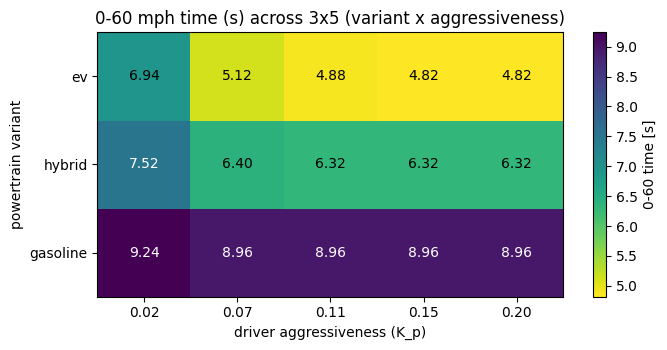

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.6))

# Replace inf (never reached 60 in T_FINAL_SWEEP) with NaN so they render
# blank rather than dominating the colormap.
display = np.where(np.isfinite(zero_to_sixty), zero_to_sixty, np.nan)
im = ax.imshow(display, aspect="auto", origin="lower", cmap="viridis_r")

ax.set_xticks(range(len(KP_GRID)))
ax.set_xticklabels([f"{kp:.2f}" for kp in KP_GRID])
ax.set_yticks(range(len(all_configs)))
ax.set_yticklabels([cfg["powertrain"] for cfg in all_configs])
ax.set_xlabel("driver aggressiveness (K_p)")
ax.set_ylabel("powertrain variant")
ax.set_title(f"0-60 mph time (s) across {len(all_configs)}x{len(KP_GRID)} "
             "(variant x aggressiveness)")

# Annotate each cell with the value.
for i in range(display.shape[0]):
    for j in range(display.shape[1]):
        val = display[i, j]
        txt = "—" if np.isnan(val) else f"{val:.2f}"
        ax.text(j, i, txt, ha="center", va="center",
                color="white" if (not np.isnan(val) and val > np.nanmean(display)) else "black",
                fontsize=10)

fig.colorbar(im, ax=ax, label="0-60 time [s]")
plt.tight_layout()
plt.show()


*Figure 3.* 0-60 mph time across the full `(powertrain, K_p)` Cartesian product. Reading right along any row, higher driver gain monotonically reduces 0-60 time until the powertrain saturates — visible as the diminishing-returns plateau across the larger $K_p$ values, where the gasoline ICE row is essentially flat (the throttle is pinned and adding gain does nothing). Reading down any column, the EV is uniformly fastest (instant torque, no spool-up), the hybrid is second, and the gasoline ICE is slowest at the same driver gain. A dash (—) would mark a cell where the vehicle didn't reach 60 mph within the simulation window; under these parameters every combination clears 60 well inside 10 s.

## Failure modes

Specific regimes where the variant story breaks or surprises:

* **Port-signature mismatch.** If a variant choice exposes the wrong number of input or output ports, the failure surfaces at *connect* time — when the parent diagram tries to wire the variant's output to the chassis input. The next cell demonstrates: we define a 2-input powertrain (illegal — the contract is 1 input, throttle) and watch `DiagramBuilder.connect` raise. This is the right place to catch the bug: at compile time, not at simulate time.
* **Build-time `Variant` vs runtime `RuntimeVariantSubsystem`.** `select_variant` resolves at build time and produces a topology bound to one choice; the others are never instantiated and contribute nothing to the JIT trace. `RuntimeVariantSubsystem` builds *all* branches and selects via a discrete input port. Use the build-time variant when the configuration is fixed per simulation; use the runtime variant when the selector must change mid-simulation (mode-switching guidance laws, gear-shift selection). The runtime variant pays the cost of running every branch each step, but it is the only one that supports a time-varying selector.
* **State vector size differs across choices.** Our gasoline powertrain has 1 continuous state (engine-torque lag); the hybrid has 2 (engine + SOC); the EV has 1 (SOC). This is fine — each variant defines its own state. But it means the simulation's parameter pytree differs across variants, which is why `simulate_batch` cannot vectorise across variants in a single kernel (only across numeric parameter values within one variant).
* **Gradients across variants.** `jax.grad` of an objective with respect to a variant choice is undefined — variants are categorical. But gradients with respect to numeric parameters *within* a fixed variant work normally; the build-time selector is fully transparent to autodiff (it ran in Python, before the trace started). The Phase-4 sweep above is the right shape: enumerate the discrete axis with `expand_all_variant_configs`, vectorise the continuous axis with `simulate_batch` (or `jax.vmap` inside).

In [16]:
# Demonstrate the port-mismatch failure: a powertrain that mistakenly
# declares two inputs (throttle + something else) instead of one. The
# parent diagram tries to wire output->input as usual; the mismatch
# fires at simulate time when the unwired input has no source.
from jaxonomy.framework.error import StaticError

class BadPowertrain(LeafSystem):
    """ILLEGAL: declares two input ports; contract requires exactly one."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.declare_input_port(name="throttle")
        self.declare_input_port(name="mystery_input")  # not in contract
        def _T(time, state, *inputs, **params):
            del time, state, params
            thr, _mystery = inputs
            return 300.0 * thr
        self.declare_output_port(_T, default_value=jnp.asarray(0.0),
                                 requires_inputs=True, name="T_wheel")


bad_variant = Variant(
    choices={
        "gasoline": lambda: GasolinePowertrain(name="powertrain"),
        "broken":   lambda: BadPowertrain(name="powertrain"),
    },
    default="gasoline",
    name="powertrain",
)

bld = DiagramBuilder()
chassis = bld.add(Chassis(M_VEH, R_WHEEL, C_D, AREA, RHO_AIR, C_RR, v0=0.0, name="chassis"))
# Select the broken choice on purpose; everything wires normally because
# select_variant has no opinion about port counts.
powertrain = bld.add(select_variant(bad_variant, name="broken"))
thr_src = bld.add(Constant(0.5, name="thr"))
grade_src = bld.add(Constant(0.0, name="grade"))
bld.connect(thr_src.output_ports[0], powertrain.input_ports[0])     # throttle
bld.connect(powertrain.output_ports[0], chassis.input_ports[0])
bld.connect(grade_src.output_ports[0], chassis.input_ports[1])
diag_bad = bld.build(name="vehicle_bad")

# The diagram builds happily — the bug shows up when we try to simulate
# (an input port has no source). create_context surfaces it as a
# StaticError.
try:
    ctx_bad = diag_bad.create_context()
    jaxonomy.simulate(diag_bad, ctx_bad, (0.0, 0.1),
                      options=SimulatorOptions(buffer_length=100))
    print("UNEXPECTED: simulate succeeded; the bug did not fire.")
except StaticError as exc:
    msg = str(exc).splitlines()[0]
    print("StaticError surfaced as expected:")
    print(" ", msg[:120])
except Exception as exc:
    # Some Jaxonomy versions raise ValueError directly.
    print(f"{type(exc).__name__} surfaced as expected:")
    print(" ", str(exc).splitlines()[0][:120])


StaticError surfaced as expected:
  Input port powertrain[1] is not connected in block powertrain at input port 1


### Diagnostics on the closed loop

We run `analyze_saturation` on the throttle signal from the gasoline run to confirm that the driver is not perpetually pinned at the rails — that would mean the gain is wrong, or the variant choice is mismatched to the scenario.

In [17]:
with warnings.catch_warnings():
    warnings.simplefilter("always")
    sat = analyze_saturation(thr_g, lower=-1.0, upper=1.0, name="throttle (gasoline)", warn=False)
print("saturation report:", sat.message)


saturation report: throttle (gasoline): 20% at upper=1, 0% at lower=-1. Total saturated: 20% of 1687 samples.


Expected: throttle saturation well under the 50% warning threshold — the driver spends most of the cycle in the linear region, briefly pinning to 1.0 during the launch and during the hill onset. If we saw >50% the right response would be to lower the driver gain or pick a quicker powertrain variant, not to silently accept the warning.

## Exercises

1. **Add a fourth variant.** Implement a fuel-cell drivetrain as `FuelCellPowertrain` — same port contract, but with two continuous states (cell stack power, tank H$_2$ mass). Add it as a fourth choice in `POWERTRAIN_VARIANT`. Verify that `dump_variant_config` now lists four options and that the heatmap row count grows to 4.
2. **Two-dimensional Cartesian product.** Extend the sweep to a `(powertrain) x (driver-aggressiveness) x (hill-grade)` grid using nested `iter_variant_configurations` (only one variant axis) plus a 2-D `simulate_batch`. Generate a `(3, 5, 3)` tensor of 0-60 times.
3. **Open-ended: take a `jax.grad` through one variant.** Pick the EV variant and fix it. Define $L(T_{em,peak}) = \int_0^{10} (v_{\text{ref}} - v(t))^2 dt$ as a function of the EV's peak torque. Build the diagram with `T_em_peak` as a `Parameter` (or compose it as a kwarg through `with_parameters`). Verify $\partial L / \partial T_{em,peak} < 0$ for the configuration above (more torque shrinks tracking error). Where does this gradient stop being useful — past what torque value does it flatten?
4. **CLI integration test.** Modify `variants_demo/model.py` so that `build_vehicle` accepts an `--env`-style argument selecting `v_ref` (e.g. 25 vs 35 m/s). Write a shell script that loops over a JSON config directory invoking `python -m jaxonomy.cli.run_variants apply` on each file and recording the resulting binding — the seed of a release-pipeline validator.
5. **`RuntimeVariantSubsystem` exercise.** Refactor the variant point into a `RuntimeVariantSubsystem` driven by a `DiscreteClock` that switches from `gasoline` to `ev` at $t=10$ s. Simulate. Why does the velocity curve show a transient at $t=10$ that the build-time `Variant` would never produce? (Hint: continuous states.)

## Key takeaways

* A `Variant(choices=..., default=..., name="X")` plus `select_variant(...)` is the build-time DSL for product-family modeling. Unselected choices are never instantiated — they contribute zero parameters, zero traces, zero JIT cost.
* `Diagram.with_config(name=choice)` (or the free function `apply_variant_config`) reconfigures a built diagram post-hoc without rebuilding from scratch. The variant-tagged subsystem is swapped in place; the rest of the diagram is preserved.
* `dump_variant_config_to_json` and `load_variant_config_from_json` persist the *binding*, not the builders. CI / release pipelines round-trip configurations through JSON; reproducibility manifests can list the active variant alongside the parameter hash.
* The `jaxonomy variants` CLI (`python -m jaxonomy.cli.run_variants list / dump / apply`) exposes the same surface as a side-effect-free check that release-engineering scripts can call.
* `expand_all_variant_configs(diagram)` returns the full Cartesian product of named variants as a list of config dicts. Paired with `simulate_batch` it produces parameter sweeps that span both topology and continuous parameters in one batched pass.

## Where to next

* [Reproducibility manifest](reproducibility_manifest.ipynb) — the manifest captures the active variant config alongside the parameter pytree, so a saved sim can be replayed against the original drivetrain choice with bit-exact equality.
* [Engine map fitting to MPC](engine_map_fitting_to_mpc.ipynb) — the gasoline variant here uses a closed-form torque curve; the engine-map tutorial shows how to fit a real 2-D map from bench data via `fit_lookup_table_2d` and drop it into the same kind of plant.
* [Battery ECM modeling (Part 1)](battery_part_1_ecm_model.ipynb) — the EV variant's SOC dynamics are deliberately stylised. The battery series develops the equivalent-circuit model that production EV simulators actually use.
* [Multirate controller](multirate_controller.ipynb) — for an inner/outer-loop motor cascade and a deeper look at `BusCreator` / `BusSelector` if you want to fan out the chassis sensors to multiple downstream consumers.

## References

* Guzzella, L. and Sciarretta, A. *Vehicle Propulsion Systems: Introduction to Modeling and Optimization*. Springer, 3rd ed., 2013. Chapter 2 covers the longitudinal model used here; Chapters 3-5 cover the gasoline / hybrid / EV powertrain families in detail.
* Hofman, T. and Salazar, M. *Hybrid Electric Vehicles: Architectures, Control Methods, and Optimization*. TU/e lecture notes, 2020. The parallel-hybrid torque-blending heuristic above is a simplified version of the rule-based controllers reviewed in Chapter 4.